Testing PCCt Scanners, see https://github.com/xcist/main/blob/master/gecatsim/examples/Sim_Sample_PCCT.py

In [1]:
from insilicoICH.ground_truth_definition.phantoms import load_phantom
age = 6.5
phantom = load_phantom(age)

import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(80, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)

for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

inserting lesion 0/3:
{'volume': 0.05, 'intensity': 80.0, 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 1/3:
{'volume': 0.275, 'intensity': 65.0, 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 2/3:
{'volume': 0.5, 'intensity': 50.0, 'lesion_type': 'IPH', 'seed': 336}




        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): [189, 233, 197]
        Size (mm): [189. 233. 197.]
        
        Number of lesions: 3
        Lesion locations [voxel index (z, x, y)]: [(94, 142, 83), (93, 96, 124), (93, 75, 116)]
        Mass effect: False
        

In [2]:
from insilicoICH.image_acquisition import Scanner

scanner = Scanner(phantom, scanner_model='Scanner_PCCT')
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing default/phantoms/0/0_ncat_adipose


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_PCCT
        Simulation Platform: CATSIM
        

In [3]:
scanner.xcist.cfg.scanner.detectorSumBins

0

Set `pitch=0` for axial scan

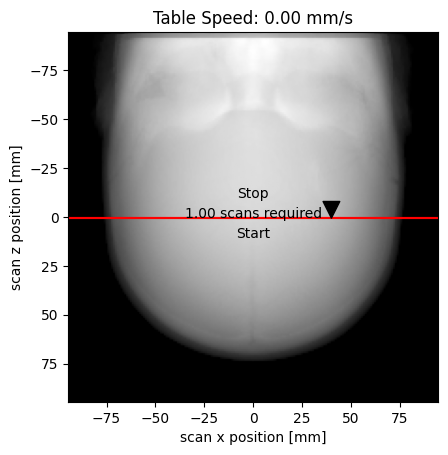

In [4]:
lesion_level_mm = (phantom.get_CT_number_phantom().shape[0]/2 -
                   phantom._lesion_coords[0][0])*phantom.dz

scans = 1  # edit me

center = lesion_level_mm
width = scanner.nominal_aperature*scans
startZ = center - width / 2
endZ = center + width / 2

scanner.scout_view(startZ, endZ)

In [5]:
if not scanner.xcist.cfg.scanner.detectorSumBins:
    scanner.xcist.do_prep = 0

In [6]:
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=300,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)

In [7]:
scanner.run_scan(**acquisition_technique)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/300 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 300/300 [02:02<00:00,  2.45it/s]

Simulation is done.



        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_PCCT
        Simulation Platform: CATSIM
        

In [8]:
import gecatsim as xc
import gecatsim.reconstruction.pyfiles.recon as recon
import matplotlib.pyplot as plt

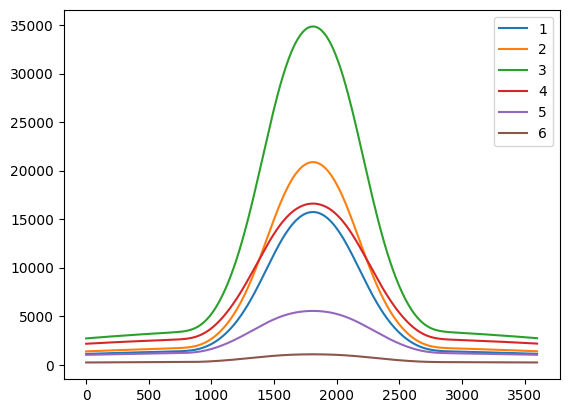

In [9]:
ct = scanner.xcist
scanFname = "%s.air" % ct.resultsName
nBin = len(ct.scanner.detectorBinThreshold)-1
air = xc.rawread(scanFname, [ct.scanner.detectorRowCount, ct.scanner.detectorColCount, nBin], 'float')
plt.plot(air[0, :, :])
plt.legend(np.arange(1,nBin+1))
plt.show()

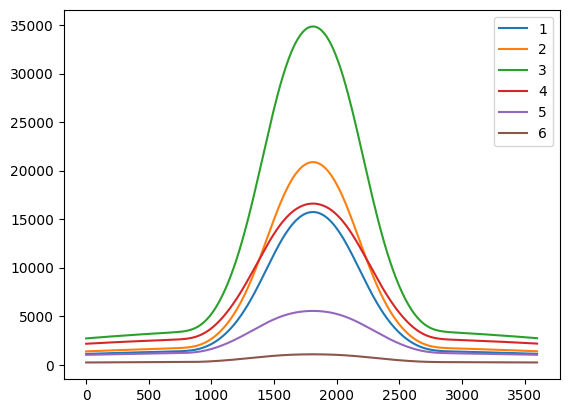

In [10]:
plt.plot(air[1, :, :])
plt.legend(np.arange(1,nBin+1))
plt.show()

In [12]:
offset = xc.rawread(ct.resultsName + '.offset', [ct.scanner.detectorRowCount, ct.scanner.detectorColCount, nBin], 'float')

In [13]:
def get_projection_data(ct):
    '''takes as input xcist cfg struct and returns ndarray'''
    nBin = len(ct.scanner.detectorBinThreshold)-1
    return xc.rawread(ct.resultsName+'.scan',
                      [ct.protocol.viewCount,
                       ct.scanner.detectorRowCount,
                       ct.scanner.detectorColCount,
                       nBin],
                      'float')
scan = get_projection_data(ct)
scan.shape

(300, 2, 3600, 6)

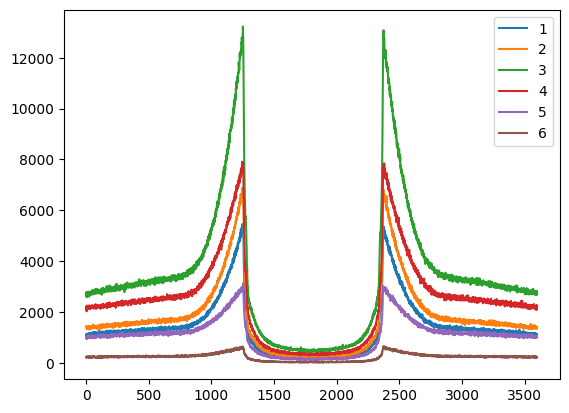

In [14]:
plt.plot(scan[0, 0, :, :])
plt.legend(np.arange(1,nBin+1))
plt.show()

In [15]:
scan.shape

(300, 2, 3600, 6)

In [16]:
thresh = 70

bins = np.array(ct.scanner.detectorBinThreshold)[:-1]

scan_lower = scan[:,:,:, bins < thresh]
scan_upper = scan[:,:,:, bins >= thresh]

air_lower = air[:,:, bins < thresh]
air_upper = air[:,:, bins >= thresh]

offset_lower = offset[:,:, bins < thresh]
offset_upper = offset[:,:, bins >= thresh]
scan_lower.shape, offset_lower.shape, air_lower.shape

((300, 2, 3600, 4), (2, 3600, 4), (2, 3600, 4))

In [17]:
scan_lower_sum = scan_lower.sum(axis=-1)
scan_upper_sum = scan_upper.sum(axis=-1)

air_lower_sum = air_lower.sum(axis=-1)
air_upper_sum = air_upper.sum(axis=-1)

offset_lower_sum = offset_lower.sum(axis=-1)
offset_upper_sum = offset_upper.sum(axis=-1)

scan_lower_sum.shape, offset_lower_sum.shape, air_lower_sum.shape

((300, 2, 3600), (2, 3600), (2, 3600))

In [18]:
def threshold_sum(scan, offset, air, bins, thresh):
    scan_lower = scan[:,:,:, bins < thresh]
    scan_upper = scan[:,:,:, bins >= thresh]
    
    air_lower = air[:,:, bins < thresh]
    air_upper = air[:,:, bins >= thresh]
    
    offset_lower = offset[:,:, bins < thresh]
    offset_upper = offset[:,:, bins >= thresh]
    #
    scan_lower_sum = scan_lower.sum(axis=-1)
    scan_upper_sum = scan_upper.sum(axis=-1)
    
    air_lower_sum = air_lower.sum(axis=-1)
    air_upper_sum = air_upper.sum(axis=-1)
    
    offset_lower_sum = offset_lower.sum(axis=-1)
    offset_upper_sum = offset_upper.sum(axis=-1)

    neglog_lower = -np.log((scan_lower_sum - offset_lower_sum)/(air_lower_sum - offset_lower_sum))
    neglog_upper = -np.log((scan_upper_sum - offset_upper_sum)/(air_upper_sum - offset_upper_sum))
    return neglog_lower, neglog_upper

neglog_lower, neglog_upper = threshold_sum(scan, offset, air, bins, thresh)
neglog_lower.shape, neglog_upper.shape 

((300, 2, 3600), (300, 2, 3600))

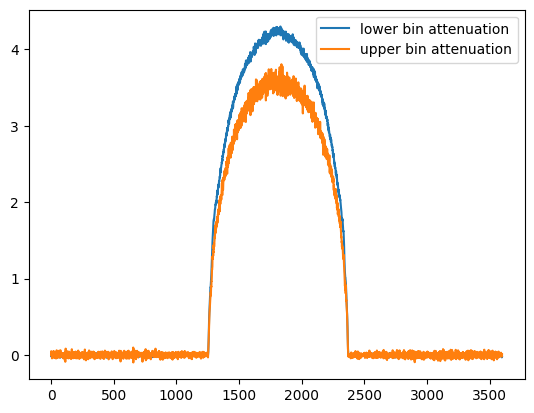

In [19]:
plt.plot(neglog_lower[0, 0, :], label='lower bin attenuation')
plt.plot(neglog_upper[0, 0, :], label='upper bin attenuation')

plt.legend()
plt.show()

In [22]:
from gecatsim.reconstruction.pyfiles import recon

In [26]:
original_name = ct.resultsName

ct.resultsName = original_name + f'_thresh_{thresh}kV_lower'
xc.rawwrite(ct.resultsName+'.prep', neglog_lower)

recon_lower = recon.recon_direct(ct)

ct.resultsName = original_name

original_name = ct.resultsName

# now upper

ct.resultsName = original_name + f'_thresh_{thresh}kV_upper'
xc.rawwrite(ct.resultsName+'.prep', neglog_upper)

recon_upper = recon.recon_direct(ct)

ct.resultsName = original_name

recon_lower.shape, recon_upper.shape

* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


((512, 512, 1), (512, 512, 1))

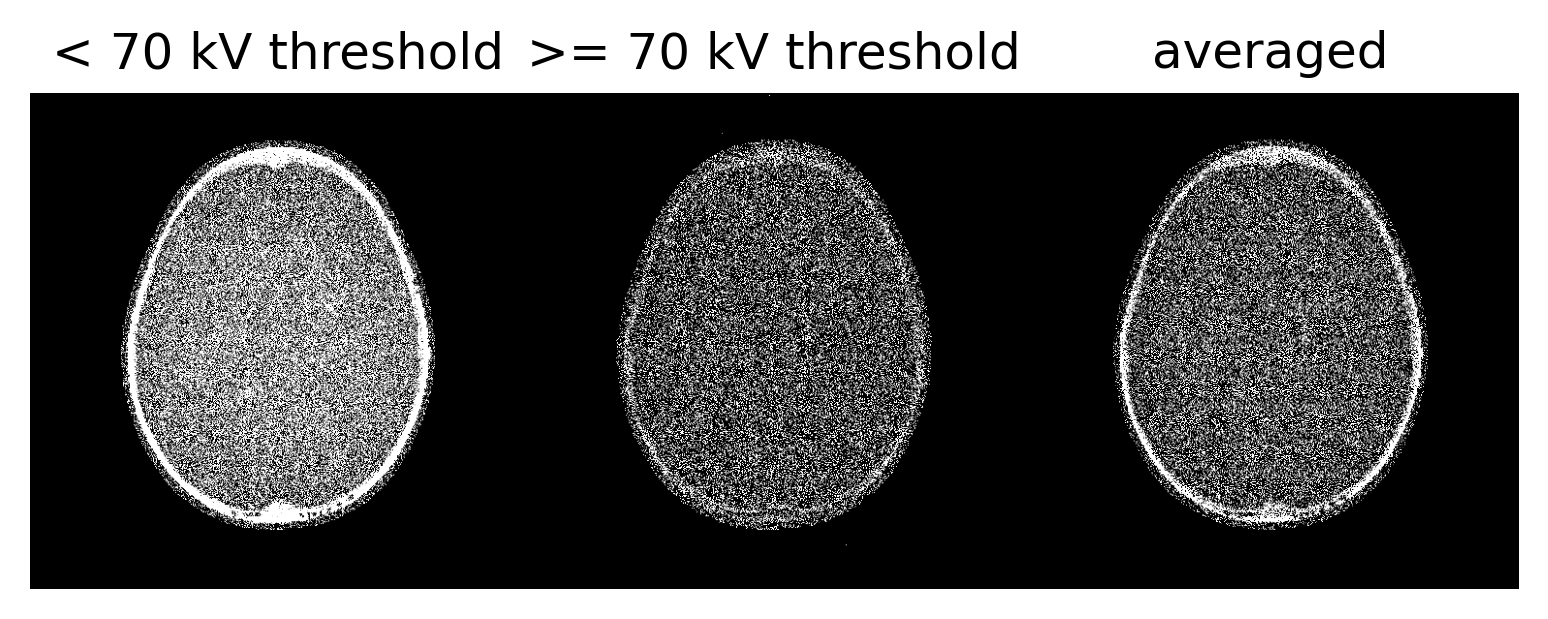

In [34]:
recon_combined = (recon_upper + recon_lower)/2

ww, wl = 80, 40
disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
f, axs = plt.subplots(1,3, gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
axs[0].imshow(recon_lower[:,:,0], **disp)
axs[0].set_title(f'< {thresh} kV threshold')
axs[0].set_axis_off()
axs[1].imshow(recon_upper[:,:,0], **disp)
axs[1].set_title(f'>= {thresh} kV threshold')
axs[1].set_axis_off()
axs[2].imshow(recon_combined[:,:,0], **disp)
axs[2].set_title(f'averaged')
axs[2].set_axis_off()